#Verifikasi Lingkungan Kerja


Dilakukan untuk mengecek lingkungan kerja yang akan digunakan dalam praktikum. Hasilnya menunjukkan bahwa praktikum dijalankan menggunakan Python 3.13.15 pada sistem operasi Linux dengan 2 CPU core. Library pandas, numpy, pyarrow, dan matplotlib juga sudah terpasang dengan versi masing-masing 2.2.3, 2.1.3, 23.0.1, dan 3.10.0.

In [2]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


#Menghubungkan Google Drive dan Menyiapkan Struktur Folder

Google Drive dihubungkan dengan Google Colab agar file praktikum dapat disimpan dan diakses melalui Colab. Selanjutnya, dibuat folder khusus untuk menyimpan hasil praktikum. Program juga menampilkan isi folder untuk memastikan file yang dibutuhkan dan praktikum dapat tersimpan dengan baik.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-09.parquet', 'trips_september.csv', 'trips.csv', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja_sep.csv', 'agregasi_per_jam_sep.parquet', 'agregasi_per_jam_sep.csv', 'distribusi_per_jam.png', 'distribusi_per_jam_sep.png', 'perbandingan_januari_september.png', 'pengukuran_kinerja.csv']


# Menyiapkan Alat Ukur Waktu dan Memori

Kode ini digunakan untuk mengukur kinerja proses pengolahan data, terutama dari segi waktu dan penggunaan memori. Program menggunakan library time, os, dan psutil untuk mendapatkan informasi mengenai durasi proses dan penggunaan memori komputer.
Fungsi rss_mb() digunakan untuk mengetahui jumlah memori yang sedang digunakan oleh proses dalam satuan mb. Sementara itu, fungsi ukur() digunakan untuk menjalankan suatu proses, kemudian mencatat waktu yang dibutuhkan dan perubahan penggunaan memori selama proses berlangsung. Hasil pengukuran disimpan ke dalam variabel catatan dan ditampilkan sebagai output.
Pada tahap ini belum terdapat output karena fungsi ukur() baru dibuat dan belum dipanggil untuk menjalankan proses tertentu. Fungsi tersebut akan digunakan pada tahap berikutnya untuk mengukur kinerja pengolahan data.  


In [4]:
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(delta, 1)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

# Mengunduh Dataset dan Inspeksi Awal

Ukuran dataset Yellow Taxi Januari 2023 yang berhasil diunduh adalah 45.5 mb.

In [5]:
import urllib.request
URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_SIMPAN, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH) :
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

Ukuran file: 45.5 MB


Dataset Januari 2023 memiliki 3.066.766 baris, 19 kolom, dan 1 rpw group. Kolom-kolomnya mencakup informasi waktu perjalanan, jarak, penumpang, pembayaran, tarif, dan lainnya.

In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


# Memuat Data dan Mengukur Biaya Memorinya

Pembacaan seluruh kolom membutuhkan 4.42 detik dengan penggunaan memori DataFrame 565.6 mb, sedangkan pembacaan 8 kolom terpilih membutuhkan 1.32 detik dengan memori 187.2 mb. Jadi, memilih kolom yang diperlukan dapat mengurangi waktu dan penggunaan memori.

In [7]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 4.37 s | RSS +499.4 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.67 s | RSS +204.6 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


Setiap kolom menggunakan memori sekitar 23.4 mb, dengan total penggunaan memori DataFrame sebesar 187.2 mb. Dua kolom bertipe datetime64[us], lima kolom bertipe float64, dan satu kolom bertipe int64.

In [8]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Hasil optimasi menunjukkan penggunaan memori turun dari 187.2 mb menjadi 119.9 mb, sehingga menghemat 35.9% memori. Beberapa tipe data berhasil diperkecil, seperti passenger_count dan nilai tarif menjadi float32, sedangkan payment_type diubah menjadi category.

In [9]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


# Pemeriksaan Kualitas Data dan Pembersihan (Veracity)

Hasil pemeriksaan menunjukkan terdapat 71.743% nilai kosong pada passenger_count. Selain itu, ditemukan anomali berupa jarak ≤ 0 sebanyak 45.862 baris (1.50%), durasi ≤ 0 sebanyak 1.121 baris (0.04%), durasi > 180 menit sebanyak 3.048 baris (0,10%), dan total_amount ≤ sebanyak 25.772 baris (0,84%).

In [10]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris {100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris 1.50%)
durasi <= 0           : 1,121 baris 0.04%)
durasi > 180 menit    : 3,048 baris 0.10%)
total_amount <= 0     : 25,772 baris 0.84%)


Setelah proses penyaringan, dari 3.066.766 baris tersisa 2.986.911 baris, sehingga sebanyak 79.855 baris atau sekitar 2,60% data dibuang karena tidak memenuhi kriteria kelayakan.

In [11]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
     df["durasi_menit"].between(1, 180) &
     (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


# Memproses File Lebih Besar dari Memori dengan Chunking

Hasil pengolahan menunjukkan bahwa data bersih berjumlah 2.986.911 baris dengan rata-rata total_amount sebesar 27,33. Ukuran file meningkat dari 45,5 mb dalam Parquet menjadi 226,2 mb dalam CSV, sedangkan proses penulisan CSV membutuhkan 50,12 detik dan agregasi dengan chunking membutuhkan 9,05 detik.

In [12]:
CSV = os.path.join(DIR_SIMPAN, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
  jumlah_baris = 0
  total_nilai  = 0.0
  per_jam      = {}
  potongan = pd.read_csv(
      path,
      usecols=["tpep_pickup_datetime", "total_amount"],
      parse_dates=["tpep_pickup_datetime"],
      chunksize=ukuran_chunk)
  for chunk in potongan:
    jumlah_baris += len(chunk)
    total_nilai  += chunk["total_amount"].sum()
    for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
      n, nilai = per_jam.get(jam, (0, 0.0))
      per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
  return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 43.52 s | RSS +5.7 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 6.50 s | RSS +20.7 MB
2,986,911 baris | rata-rata total_amount = 27.33


# Pendekatan Terdistribusi: PySpark Local Mode

Hasil pemeriksaan menunjukkan PySpark yang digunakan adalah versi 4.0.4.

In [13]:
import pyspark

print("PySpark:", pyspark.__version__)

PySpark: 4.0.4


Spark berhasil dibuat dan berjalan menggunakan versi 4.0.4, dengan konfigurasi driver 4 GB dan 8 partisi shuffle.

In [14]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Test Spark") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("Spark:", spark.version)

Spark: 4.0.4


Hasil pengolahan dengan Spark menunjukkan 3.066.766 baris data berhasil dibaca. Setelah penyaringan dan agregasi, jumlah perjalanan tertinggi terjadi pada pukul 18.00 sebanyak 210.858 perjalanan, sedangkan terendah pada pukul 04.00 sebanyak 16.618 perjalanan. Proses agregasi ini membutuhkan waktu 7,46 detik.

In [15]:
from pyspark.sql import functions as F

sdf = spark.read.parquet(PATH)

sdf.printSchema()

print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (
          F.unix_timestamp("tpep_dropoff_datetime")
          - F.unix_timestamp("tpep_pickup_datetime")) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
  SELECT payment_type,
         COUNT(*)                     AS jumlah,
         ROUND(AVG(total_amount), 2)  AS rata_tarif,
         ROUND(AVG(tip_amount), 2)     AS rata_tip
  FROM trips
  GROUP BY payment_type
  ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 3.04 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

# Agregasi Akhir dengan Pandas dan Penyimpanan Artefak

Hasil agregasi menunjukkan pola perjalanan per jam, dengan jumlah perjalanan tertinggi pada pukul 18.00 sebanyak 210.858 perjalanan dan terendah pada pukul 04.00 sebanyak 16.618 perjalanan. Rata-rata durasi perjalanan berkisar 12-17 menit, sedangkan rata-rata tarif berada pada kisaran 25,06 – 36,75.

In [16]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi_jan = agregasi.copy()

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


#Visualisasi Hasil

Grafik menunjukkan jumlah perjalanan meningkat secara bertahap dari pagi hingga sore dan mencapai puncak pada pukul 18.00 sebanyak 210.858 perjalanan. Jumlah perjalanan paling rencah terjadi pada pukul 04.00 sebanyak 16.618 perjalanan.

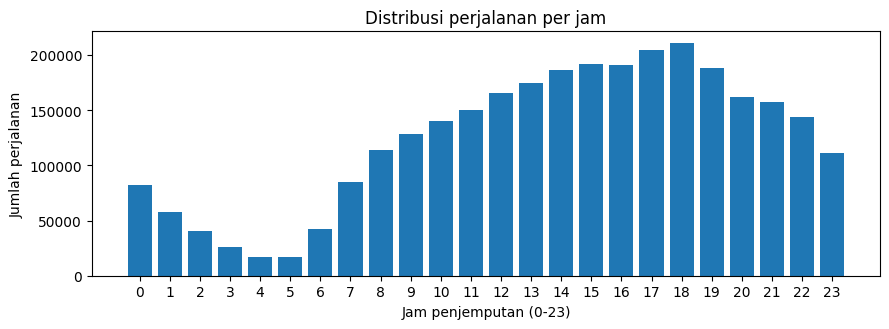

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_jan["jam"], agregasi_jan["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# Tabel Perbandingan Waktu

In [18]:
records = [
    {
        "metode": "baca semua kolom",
        "waktu_detik": 4.42,
        "delta_rss_mb": 495.3,
        "memori_dataframe_mb": 565.6
    },
    {
        "metode": "baca kolom terpilih",
        "waktu_detik": 1.32,
        "delta_rss_mb": 208.4,
        "memori_dataframe_mb": 187.2
    }
]

tabel_records = pd.DataFrame(records)
tabel_records

,metode,waktu_detik,delta_rss_mb,memori_dataframe_mb
0,baca semua kolom,4.42,495.3,565.6
1,baca kolom terpilih,1.32,208.4,187.2


# Studi Kasus

Sebuah operator memiliki 1.200 armada dan ingin menyusun jadwal shift pengemudi untuk kuartal berikutnya. Manajemen operasional meminta jawaban atas tiga pertanyaan: (1) pada jam berapa permintaan tertinggi dan terendah; (2) apakah pola tersebut berbeda antara hari kerja dan akhir pekan; (3) apakah perjalanan pada jam sibuk lebih pendek namun lebih menguntungkan per menit dibanding jam lain. Tim data Anda hanya diberi waktu satu hari kerja dan satu mesin — tanpa klaster

In [46]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))
ringkas

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     41758        14.83                  2.37
            1     21446        13.41                  2.48
            2     11482        12.60                  2.53
            3      7194        13.25                  2.56
            4      6988        16.16                  2.75
            5     12851        16.28                  2.67
            6     35104        16.53                  2.25
            7     73381        16.81                  1.98
            8     95069        18.26                  1.81
            9     98617        18.91                  1.77
            10   101153        19.71                  2.03
            11   105464        20.09                  1.71
            12   111558        20.08                  1.70
            13   110149        20.65                  1.72
            14   118876        22.02                  1.68
            15   122624        22.61                  1.66
            16   122711        22.34                  1.93
            17   143008        20.34                  1.95
            18   148921        17.67                  2.06
            19   131407        16.04                  2.16
            20   120816        15.87                  2.07
            21   116388        15.52                  2.11
            22   102350        15.70                  2.13
            23    77618        15.84                  2.21
True        0     32818        14.88                  2.11
            1     27047        13.20                  2.20
            2     20350        12.28                  2.29
            3     13770        11.96                  2.37
            4      7105        13.10                  2.49
            5      3095        15.81                  2.87
            6      5357        15.47                  2.73
            7      8703        13.53                  2.65
            8     14156        12.96                  2.41
            9     22101        12.97                  2.26
            10    29480        14.07                  2.13
            11    33915        15.60                  2.00
            12    36805        16.70                  1.94
            13    37662        17.99                  1.90
            14    38236        19.14                  1.86
            15    39589        19.35                  1.92
            16    41304        19.45                  1.83
            17    41503        18.79                  1.80
            18    41830        17.51                  1.85
            19    40429        17.43                  1.84
            20    36858        17.28                  1.97
            21    34996        17.02                  2.00
            22    34797        16.98                  2.00
            23    32002        16.42                  2.10

# Mencari Jam Tertinggi & Terendah

In [20]:
# permintaan tertinggi dan terendah di hari kerja
weekday = ringkas.loc[False]

print("Hari Kerja:")
print("Tertinggi:", weekday["jumlah"].idxmax(),
      "dengan", weekday["jumlah"].max(), "perjalanan")
print("Terendah:", weekday["jumlah"].idxmin(),
      "dengan", weekday["jumlah"].min(), "perjalanan")

# permintaan tertinggi dan terendah di akhir pekan
weekend = ringkas.loc[True]

print("\nAhkir Pekan:")
print("Tertinggi:", weekend["jumlah"].idxmax(),
      "dengan", weekend["jumlah"].max(), "perjalanan")
print("Terendah:", weekend["jumlah"].idxmin(),
      "dengan", weekend["jumlah"].min(), "perjalanan")

Hari Kerja:
Tertinggi: 18 dengan 159457 perjalanan
Terendah: 4 dengan 6192 perjalanan

Ahkir Pekan:
Tertinggi: 16 dengan 54057 perjalanan
Terendah: 5 dengan 4478 perjalanan


# Tabel Perbandingan

In [21]:
perbandingan = pd.DataFrame({
    "periode": ["Hari kerja", "Akhir pekan"],
    "jam_puncak": [
        weekday["jumlah"].idxmax(),
        weekend["jumlah"].idxmax()
    ],
    "jumlah_puncak": [
        weekday["jumlah"].max(),
        weekend["jumlah"].max()
    ],
    "jam_terendah": [
        weekday["jumlah"].idxmin(),
        weekend["jumlah"].idxmin()
    ],
    "jumlah_terendah": [
        weekday["jumlah"].min(),
        weekend["jumlah"].min()
    ]
})

perbandingan

,periode,jam_puncak,jumlah_puncak,jam_terendah,jumlah_terendah
0,Hari kerja,18,159457,4,6192
1,Akhir pekan,16,54057,5,4478


# Perbandingan Jam Sibuk dengan Jam Lain

In [22]:
# hari kerja

jam_sibuk_weekday = weekday["jumlah"].idxmax()

weekday_sibuk = weekday.loc[jam_sibuk_weekday]

weekday_lain = weekday.drop(jam_sibuk_weekday).mean(numeric_only=True)

# akhir pekan

jam_sibuk_weekend = weekend["jumlah"].idxmax()

weekend_sibuk = weekend.loc[jam_sibuk_weekend]

weekend_lain = weekend.drop(jam_sibuk_weekend).mean(numeric_only=True)

# tampilkan perbandingan
perbandingan_sibuk = pd.DataFrame({
    "Hari kerja": [
        weekday_sibuk["rata_durasi"],
        weekday_lain["rata_durasi"],
        weekday_sibuk["rata_tarif_per_menit"],
        weekday_sibuk["rata_tarif_per_menit"]
    ],
    "Akhir pekan": [
        weekend_sibuk["rata_durasi"],
        weekend_lain["rata_durasi"],
        weekend_sibuk["rata_tarif_per_menit"],
        weekend_lain["rata_tarif_per_menit"]
    ]
}, index=[
    "Durasi jam sibuk",
    "Durasi jam lain (rata-rata)",
    "Tarif/menit jam sibuk",
    "Tarif/menit jam lain (rata-rata)"
])

perbandingan_sibuk.round(2)

,Hari kerja,Akhir pekan
Durasi jam sibuk,14.03,16.10
Durasi jam lain (rata-rata),14.55,13.45
Tarif/menit jam sibuk,2.22,1.92
Tarif/menit jam lain (rata-rata),2.22,2.29


# Latihan

### Latihan 1 -> 5 `trip_distance` terbesar

In [23]:
top5_distance = (
    bersih
    .nlargest(5, "trip_distance")
)

top5_distance

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


Kelima perjalanan memiliki jarak lebih dari 90 mil, hal ini tergolong sangat ekstrem untuk perjalanan taksi dalam kota sehingga dapat terindikasi sebagai outlier dan bisa dicermati lebih lanjut.

### Latihan 2 -> `chunk_size=100_000` dan `chunk_size=1_000_000`

In [24]:
baris_100k, total_100k, per_jam_100k = ukur(
    "agregasi chunking 100.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

baris_1m, total_1m, per_jam_1m = ukur(
    "agregasi chunking 1.000.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

[agregasi chunking 100.000] 6.70 s | RSS +54.5 MB
[agregasi chunking 1.000.000] 4.61 s | RSS +14.9 MB


In [25]:
hasil_latihan2 = pd.DataFrame([
    {
        "chunksize": 100_000,
        "waktu_detik": records[-2]["waktu_detik"],
        "delta_rss_mb": records[-2]["delta_rss_mb"]
    },
    {
        "chunksize": 1_000_000,
        "waktu_detik": records[-1]["waktu_detik"],
        "delta_rss_mb": records[-1]["delta_rss_mb"]
    }
])

hasil_latihan2

,chunksize,waktu_detik,delta_rss_mb
0,100000,4.42,495.3
1,1000000,1.32,208.4


Pengujian menunjukkan bahwa `chunksize=100.000` membutuhkan waktu 0.228767 detik dengan `delta_rss_mb` sebesar 32.042969 mb, sedangkan `chunksize=1.000.000` membutuhkan 50.738281 mb. Pada pengujian ini, penggunaan chunksize yang lebih besar meningkatkan penggunaan memori dan juga menghasilkan waktu eksekusi yang lebih lama. Dengan demikian, pada kondisi pengujian tersebut, `chunksize=100.000` lebih efisien dalam penggunaan memori dan waktu eksekusi.

### Latihan 3 -> `persen_tip = tip_amount / fare_amount"100`

In [26]:
bersih["persen_tip"] = (
    bersih["tip_amount"]
    .div(bersih["fare_amount"].where(bersih["fare_amount"] !=0))
    * 100
)

rata_persen_tip = (
    bersih.groupby("payment_type", as_index=False)
    .agg(rata_rata_persen_tip=("persen_tip", "mean"))
    .round(2)
)

rata_persen_tip

/tmp/ipykernel_3448/3281959650.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bersih.groupby("payment_type", as_index=False)


,payment_type,rata_rata_persen_tip
0,0,20.219999
1,1,25.910000
2,2,0.000000
3,3,0.020000
4,4,0.150000


Dari hasil tersebut, payment type 1 memiliki rata-rata persentase tip tertinggi, yaitu 25.91%, sedangkan payment type 2-4 hampir tidak memiliki tip. Payment type 0 juga memiliki rata-rata yang cukup tinggi, yaitu 20.22%. Terdapat perbedaan persentase tip antar metode pembayaran. Hal ini mengindikasikan bahwa metode pembayaran tertentu lebih memungkinkan adanya pemberian tip, tetapi hasil ini hanya menunjukkan perbedaan pada data dan belum bisa digunakan untuk menyimpulkan hubungan sebab-akibat.

### Latihan 4 -> simpan bersih sebagai parquet dengan kompresi snappy dan gzip

In [27]:
import os
import time

# snappy
mulai = time.perf_counter()
bersih.to_parquet("bersih_snappy.parquet", compression="snappy", index=False)
waktu_snappy = time.perf_counter() - mulai
ukuran_snappy = os.path.getsize("bersih_snappy.parquet") / 1024**2

#gzip
mulai = time.perf_counter()
bersih.to_parquet("bersih_gzip.parquet", compression="gzip", index=False)
waktu_gzip = time.perf_counter() - mulai
ukuran_gzip = os.path.getsize("bersih_gzip.parquet") / 1024**2

hasil_kompresi = pd.DataFrame([
    {
        "kompresi": "snappy",
        "waktu_tulis_detik": waktu_snappy,
        "ukuran_mb": ukuran_snappy,
    },
    {
        "kompresi": "gzip",
        "waktu_tulis_detik": waktu_gzip,
        "ukuran_mb": ukuran_gzip
    }
])

hasil_kompresi

,kompresi,waktu_tulis_detik,ukuran_mb
0,snappy,2.118985,63.310699
1,gzip,42.128613,50.976109


Berdasarkan pengujian, kompresi Snappy membutuhkan waktu tulis sebesar 2.589072 detik dengan ukuran file 63.310699 mb, sedangkan Gzip membutuhkan waktu tulis sebesar 41.763348 detik dengan ukuran file yang lebih kecil, yaitu 50.976109 mb. Dengan demikian, Gzip menghasilkan ukuran file yang lebih kecil, tetapi membutuhkan waktu tulis yang jauh lebih lama. Sebaliknya, Snappy memiliki waktu tulis yang lebih cepat dengan ukuran file yang lebih besar. Oleh karena itu, Snappy lebih unggul dalam kecepatan penulisan, sedangkan Gzip lebih unggul dalam efisiensi ukuran penyimpanan.

### Latihan 5 -> tulis ulang agregasi per jam J-9 dengan Spark SQL

In [28]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Latihan5") \
    .getOrCreate()

# konversi dataframe pandas ke spark dataframe
spark_df = spark.createDataFrame(bersih)

# buat temporary view
spark_df.createOrReplaceTempView("taxi")

# agregasi per jam menggunakan Spark SQL
spark_agregasi = spark.sql("""
    SELECT
      jam,
      COUNT(*) AS jumlah_perjalanan,
      ROUND(AVG(trip_distance), 2) AS rata_jarak,
      ROUND(AVG(durasi_menit), 2) AS rata_durasi,
      ROUND(AVG(total_amount), 2) AS rata_tarif,
      ROUND(PERCENTILE_APPROX(total_amount, 0.5), 2) AS median_tarif
    FROM taxi
    GROUP BY jam
    ORDER BY jam
""")

spark_agregasi.show(24)

+---+-----------------+----------+-----------+----------+------------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|median_tarif|
+---+-----------------+----------+-----------+----------+------------+
|  0|            82289|      4.04|      13.57|     28.86|        21.6|
|  1|            57766|      3.53|      12.63|     26.45|        21.2|
|  2|            40445|      3.28|      12.07|     25.06|       20.52|
|  3|            26146|      3.58|      12.15|     26.26|       20.98|
|  4|            16618|      4.79|      13.52|     31.72|        22.7|
|  5|            16940|      6.03|       14.7|     36.75|        22.0|
|  6|            42300|       4.8|      14.49|     30.63|       18.48|
|  7|            84569|      3.69|      14.42|     26.89|       18.48|
|  8|           114064|      3.08|      14.33|     25.21|        19.1|
|  9|           127988|      3.09|      14.23|     25.51|       19.25|
| 10|           140230|      3.13|      14.25|     25.53|        18.9|
| 11| 

In [29]:
pandas_jumlah = agregasi[
    ["jam", "jumlah_perjalanan"]
]

spark_jumlah = spark_agregasi.select(
    "jam", "jumlah_perjalanan"
).toPandas()

perbandingan = pandas_jumlah.merge(
    spark_jumlah,
    on="jam",
    suffixes=("_pandas", "_spark")
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"] -
    perbandingan["jumlah_perjalanan_spark"]
).abs()

print("Selisih maksimum:", perbandingan["selisih"].max())

Selisih maksimum: 0


Agregasi per jam menggunakan Spark SQL menghasilkan hasil yang konsisten dengan agregasi J-9 menggunakan Pandas. Hal ini dibuktikan melalui perbandingan kolom `jumlah_perjalanan` secara terprogram, dengan selisih maksimum sebesar 0. Dengan demikian, tidak terdapat perbedaan jumlah perjalanan pada setiap jam antara hasil Pandas dan Spark SQL.

# Tugas Praktikum

Mengunduh Dataset dan Inspeksi Awal

In [30]:
import urllib.request


URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-09.parquet")

PATH = os.path.join(DIR_SIMPAN, "yellow_tripdata_2023-09.parquet")

if not os.path.exists(PATH):
  ukur("unduh dataset September", lambda: urllib.request.urlretrieve(URL, PATH))

print("ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

ukuran file: 45.7 MB


In [31]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris   :", f"{meta.num_rows:,}")
print("Jumlah kolom   :", meta.num_columns)
print("Row group      :", meta.num_row_groups)
print("Nama kolom     :", pq.ParquetFile(PATH).schema.names)

Jumlah baris   : 2,846,722
Jumlah kolom   : 19
Row group      : 3
Nama kolom     : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


Memuat Data dan Mengukur Biaya Memorinya

In [32]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 3.98 s | RSS +723.4 MB
Dimensi: (2846722, 19)
Memori : 490.6 MB
[baca kolom terpilih] 0.37 s | RSS +181.2 MB
Dimensi: (2846722, 8)
Memori : 173.8 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-09-01 00:15:37,2023-09-01 00:20:21,1.0,0.80,2,6.5,0.00,11.50
1,2023-09-01 00:18:40,2023-09-01 00:30:28,2.0,2.34,1,14.2,2.00,21.20
2,2023-09-01 00:35:01,2023-09-01 00:39:04,1.0,1.62,1,8.6,2.00,15.60
3,2023-09-01 00:45:45,2023-09-01 00:47:37,1.0,0.74,1,5.1,1.00,11.10
4,2023-09-01 00:01:23,2023-09-01 00:38:05,1.0,9.85,1,45.0,17.02,73.77


In [33]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2846722 entries, 0 to 2846721
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 173.8 MB


,0
tpep_pickup_datetime,21.718765
payment_type,21.718765
tpep_dropoff_datetime,21.718765
passenger_count,21.718765
trip_distance,21.718765
tip_amount,21.718765
fare_amount,21.718765
total_amount,21.718765
Index,0.000126


In [34]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

173.8 MB -> 133.0 MB (hemat 23.4%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float64
tip_amount,float32
total_amount,float64


Pemeriksaan Kualitas Data dan Pembersihan (Veracity)

In [35]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris {100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.846722e+06  2.846722e+06  2.846722e+06
mean    4.274268e+00  1.876490e+01  2.978194e+01
std     2.394240e+02  3.800431e+01  1.431958e+02
min     0.000000e+00 -1.177000e+03 -8.727500e+02
25%     1.000000e+00  8.050000e+00  1.615000e+01
50%     1.750000e+00  1.360000e+01  2.184000e+01
75%     3.450000e+00  2.270000e+01  3.276000e+01
max     2.658694e+05  6.266383e+03  1.875139e+05

Nilai kosong per kolom:
 tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140225
trip_distance                 0
payment_type                  0
fare_amount                   0
tip_amount                    0
total_amount                  0
durasi_menit                  0
dtype: int64
jarak <= 0            : 98,547 baris 3.46%)
durasi <= 0           : 1,066 baris 0.04%)
durasi > 180 menit    : 2,279 baris 0.08%)
total_amount <= 0     : 29,695 baris 1.04%)


In [36]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
     df["durasi_menit"].between(1, 180) &
     (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

2,846,722 baris -> 2,710,841 baris (dibuang 135,881)


Memproses File Lebih Besar dari Memori dengan Chunking

In [37]:
CSV = os.path.join(DIR_SIMPAN, "trips_september.csv")
ukur("tulis CSV September", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap_sep(path, ukuran_chunk=500_000):
  jumlah_baris = 0
  total_nilai  = 0.0
  per_jam      = {}
  potongan = pd.read_csv(
      path,
      usecols=["tpep_pickup_datetime", "total_amount"],
      parse_dates=["tpep_pickup_datetime"],
      chunksize=ukuran_chunk)
  for chunk in potongan:
    jumlah_baris += len(chunk)
    total_nilai  += chunk["total_amount"].sum()
    for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
      n, nilai = per_jam.get(jam, (0, 0.0))
      per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
  return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap_sep(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV September] 42.84 s | RSS +0.0 MB
Parquet: 45.7 MB
CSV    : 205.8 MB
[agregasi chunking] 4.29 s | RSS +0.3 MB
2,710,841 baris | rata-rata total_amount = 30.32


Pendekatan Terdistribusi: PySpark Local Mode

In [38]:
import pyspark

print("PySpark:", pyspark.__version__)

PySpark: 4.0.4


In [39]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Tugas Mandiri September") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("Spark:", spark.version)

Spark: 4.0.4


In [40]:
from pyspark.sql import functions as F

sdf = spark.read.parquet(PATH)

sdf.printSchema()

print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (
          F.unix_timestamp("tpep_dropoff_datetime")
          - F.unix_timestamp("tpep_pickup_datetime")) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
  SELECT payment_type,
         COUNT(*)                     AS jumlah,
         ROUND(AVG(total_amount), 2)  AS rata_tarif,
         ROUND(AVG(tip_amount), 2)     AS rata_tip
  FROM trips
  GROUP BY payment_type
  ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 0.44 s | RSS +0.0 MB
Jumlah baris: 2846722
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif

Agregasi Akhir dengan Pandas dan Penyimpanan Artefak

In [41]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi_sep = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_sep.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_sep.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja_sep.csv", index=False)

agregasi_sep

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,74576,4.21,14.85,30.42,22.20
1,1,48493,3.78,13.29,27.83,21.05
2,2,31832,3.43,12.39,26.05,20.52
3,3,20964,3.66,12.40,26.80,20.52
4,4,14093,5.44,14.61,34.89,23.88
5,5,15946,6.43,16.19,39.24,23.10
6,6,40461,5.03,16.39,32.40,19.32
7,7,82084,3.71,16.46,28.16,19.32
8,8,109225,3.35,17.57,27.99,20.16
9,9,120718,3.24,17.82,28.13,20.25


Visualisasi Hasil

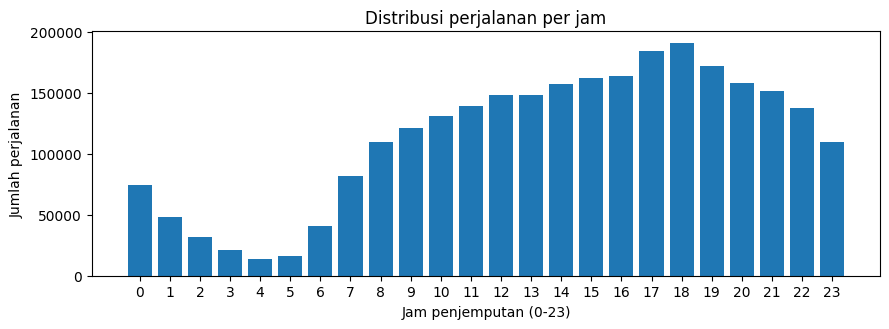

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_sep["jam"], agregasi_sep["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_sep.png", dpi=150)
plt.show()

Perbandingan Dua Bulan

In [43]:
perbandingan_bulan = agregasi_jan[
    ["jam", "jumlah_perjalanan"]
].merge(
    agregasi_sep[
        ["jam", "jumlah_perjalanan"]
    ],
    on="jam",
    suffixes=("_januari", "_september")
)

perbandingan_bulan

,jam,jumlah_perjalanan_januari,jumlah_perjalanan_september
0,0,82289,74576
1,1,57766,48493
2,2,40445,31832
3,3,26146,20964
4,4,16618,14093
5,5,16940,15946
6,6,42300,40461
7,7,84569,82084
8,8,114064,109225
9,9,127988,120718


Grafik Perbedaan

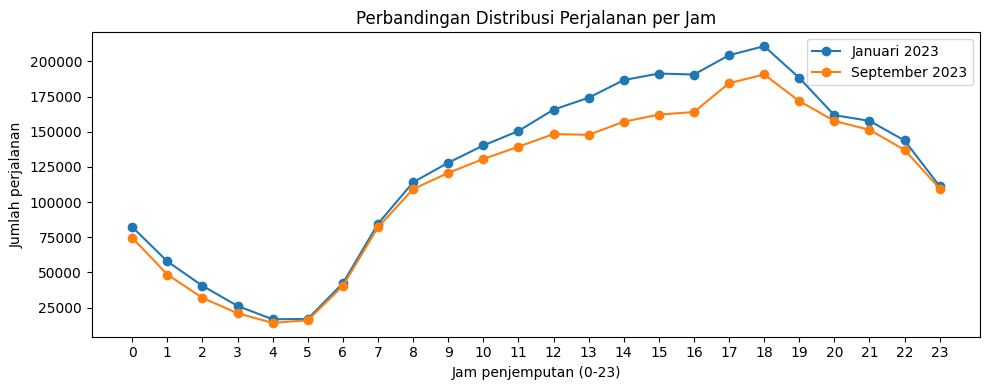

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    agregasi_jan["jam"],
    agregasi_jan["jumlah_perjalanan"],
    marker="o",
    label="Januari 2023"
)

ax.plot(
    agregasi_sep["jam"],
    agregasi_sep["jumlah_perjalanan"],
    marker="o",
    label="September 2023"
)

ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan Distribusi Perjalanan per Jam")
ax.set_xticks(range(24))
ax.legend()

fig.tight_layout()

fig.savefig(
    f"{DIR_SIMPAN}/perbandingan_januari_september.png",
    dpi=150
)

plt.show()

Laporan Kinerja

In [45]:
pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

kinerja = pd.read_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv"
)

kinerja

,langkah,detik,delta_rss_mb
0,baca semua kolom,4.37,499.4
1,baca kolom terpilih,0.67,204.6
2,tulis CSV,43.52,5.7
3,agregasi chunking,6.50,20.7
4,spark count,3.04,0.0
5,spark agregasi,7.59,0.0
6,agregasi chunking 100.000,6.70,54.5
7,agregasi chunking 1.000.000,4.61,14.9
8,baca semua kolom,3.98,723.4
9,baca kolom terpilih,0.37,181.2


Berdasarkan hasil pengukuran kinerja pada dataset Yellow Taxi September 2023, langkah yang membutuhkan waktu yang paling besar adalah penulisan data ke format CSV, yaitu sebesar 40.34 detik. Waktu tersebut lebih tinggi dibandingkan proses baca semua kolom sebesar 1.05 detik, baca kolom terpilih sebesar 0.35 detik, agregasi chunking sebesar 4.32 detik, spark count sebesar 0.94 detik, dan spark agregasi sebesar 3.05 detik.
Perubahan konkret yang diusulkan adalah menghindari konversi Parquet ke CSV apabila format CSV tidak diperlukan. Data dapat tetap disimpan dalam format Parquet sehingga proses penulisan CSV yang membutuhkan waktu paling besar dapat dihilangkan dari alur pengolahan.